## Packages


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from typing import Tuple
import sys
from pathlib import Path
from datetime import datetime
import os
import pyro

# Add parent directory to path to import Models
# This works for notebooks in the Experiments folder
project_root = Path.cwd().parent if Path.cwd().name == 'Experiments' else Path.cwd()
sys.path.insert(0, str(project_root))

# Setup results directory
results_dir = project_root / "results" / "ood"
results_dir.mkdir(parents=True, exist_ok=True)
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
stats_dir = results_dir / "statistics"
stats_dir.mkdir(exist_ok=True)

print(f"Results will be saved to: {results_dir}")

# Import from Models folder
from Models.MC_Dropout import (
    MCDropoutRegressor,
    train_model,
    mc_dropout_predict,
    gaussian_nll,
    beta_nll,
    plot_toy_data,
    plot_uncertainties,
    normalize_x,
    normalize_x_data
)

from Models.Deep_Ensemble import (
    train_ensemble_deep,
    ensemble_predict_deep
)

from Models.BNN import (
    train_bnn,
    bnn_predict,
    normalize_x as bnn_normalize_x,
    normalize_x_data as bnn_normalize_x_data
)

from Models.BAMLSS import (
    fit_bamlss,
    bamlss_predict
)

from utils.device import get_device
from utils.plotting import plot_toy_data, plot_uncertainties_ood
import utils.results_save as results_save_module
from utils.results_save import save_plot, save_statistics, save_summary_text, save_summary_statistics
from utils.plotting import plot_data_with_ood_regions

# Import helper functions for OOD experiments
from utils.ood_experiments import (
    run_mc_dropout_ood_experiment,
    run_deep_ensemble_ood_experiment,
    run_bnn_ood_experiment,
    run_bamlss_ood_experiment
)

# Set the module-level directories for results_save
results_save_module.plots_dir = plots_dir
results_save_module.stats_dir = stats_dir


Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


Results will be saved to: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\ood
CUDA not available. Using CPU.
CUDA not available. Using CPU.


## Device Setup


In [2]:
device = get_device()


CUDA not available. Using CPU.


## Generate Toy Datasets


In [3]:
# Reproducibility
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

# ----- Data generation for linear function with homo/heteroscedastic noise -----
# f(x) = 0.7x + 0.5
# noise_type: 'homoscedastic' (σ(x) = 0.20) or 'heteroscedastic' (σ(x) = 0.10 + 0.2(0.5 + 0.5sin(x)))
def generate_toy_regression(n_train=1000, train_range=(-5, 10.0), train_ranges=None,
                           ood_ranges=None, grid_points=1000, noise_type='heteroscedastic', type = "linear", n_ood=0):
    """
    Generate toy regression data with support for multiple training ranges and OOD regions.
    
    Args:
        n_train: Number of training samples
        train_range: Single training range tuple (min, max) - for backward compatibility
        train_ranges: List of training range tuples [(min1, max1), (min2, max2), ...]
                     If provided, overrides train_range. Samples are distributed proportionally.
        ood_ranges: List of OOD range tuples [(min1, max1), (min2, max2), ...]
                   If None, OOD is automatically everything NOT in training ranges
        grid_points: Number of grid points for evaluation
        noise_type: 'homoscedastic' or 'heteroscedastic'
        type: 'linear' or 'sin'
        n_ood: Number of simulated OOD data points (same DGP). Only when ood_ranges is not None.
    
    Returns:
        (x_train, y_train, x_grid, y_grid_clean, ood_mask, x_ood, y_ood)
    """
    # Handle train_ranges: if provided, use it; otherwise use train_range as single range
    if train_ranges is None:
        train_ranges = [train_range]
    else:
        # train_ranges provided, ignore train_range
        pass
    
    # Sample training data proportionally from each training range
    # Calculate total width of all training ranges
    total_width = sum([r[1] - r[0] for r in train_ranges])
    
    # Sample from each range proportionally
    x_train_list = []
    samples_allocated = 0
    for idx, train_r in enumerate(train_ranges):
        low, high = train_r
        range_width = high - low
        # Number of samples proportional to range width
        if idx == len(train_ranges) - 1:
            # Last range gets remaining samples to ensure exact total
            n_samples = n_train - samples_allocated
        else:
            n_samples = int(n_train * range_width / total_width)
            samples_allocated += n_samples
        x_train_range = np.random.uniform(low, high, size=(n_samples, 1))
        x_train_list.append(x_train_range)
    
    x_train = np.vstack(x_train_list)
    # Shuffle to mix samples from different ranges
    indices = np.random.permutation(len(x_train))
    x_train = x_train[indices]
    
    if type == "linear":
        # Linear function: f(x) = 0.7x + 0.5
        f_clean = lambda x: 0.7 * x + 0.5
        y_clean_train = f_clean(x_train)
    elif type == "sin":
        f_clean = lambda x:  x * np.sin(x) + x
        y_clean_train = f_clean(x_train)
    else:
        raise ValueError("type must be 'linear', 'sin'")

    # Define noise variance σ²(x)
    if noise_type == 'homoscedastic':
        # Homoscedastic: σ(x) = 0.8
        sigma = 1
        sigma_train = np.full_like(x_train, sigma)
    elif noise_type == 'heteroscedastic':
        # Heteroscedastic: 
        sigma_train = np.abs(2.5 * np.sin(0.5*x_train +5))
    else:
        raise ValueError("noise_type must be 'homoscedastic' or 'heteroscedastic'")
    
    # Generate noise: ε | x ~ N(0, σ²(x))
    epsilon = np.random.normal(0.0, sigma_train, size=(n_train, 1))
    y_train = y_clean_train + epsilon

    # Simulated OOD data points (same DGP, not used for training)
    if n_ood > 0 and ood_ranges is not None:
        ood_width_total = sum(r[1] - r[0] for r in ood_ranges)
        x_ood_list = []
        samples_ood_allocated = 0
        for idx, (low, high) in enumerate(ood_ranges):
            range_w = high - low
            if idx == len(ood_ranges) - 1:
                n_ood_part = n_ood - samples_ood_allocated
            else:
                n_ood_part = int(n_ood * range_w / ood_width_total)
                samples_ood_allocated += n_ood_part
            x_ood_list.append(np.random.uniform(low, high, size=(n_ood_part, 1)))
        x_ood = np.vstack(x_ood_list)
        y_clean_ood = f_clean(x_ood)
        if noise_type == 'homoscedastic':
            sigma_ood = np.full_like(x_ood, sigma)
        else:
            sigma_ood = np.abs(2.5 * np.sin(0.5 * x_ood + 5))
        y_ood = y_clean_ood + np.random.normal(0.0, sigma_ood, size=x_ood.shape)
        x_ood = x_ood.astype(np.float32)
        y_ood = y_ood.astype(np.float32)
    else:
        x_ood = np.array([]).reshape(0, 1).astype(np.float32)
        y_ood = np.array([]).reshape(0, 1).astype(np.float32)

    # Determine grid extent: from min of all training/OOD ranges to max
    all_ranges = train_ranges + (ood_ranges if ood_ranges else [])
    grid_start = min([r[0] for r in all_ranges])
    grid_end = max([r[1] for r in all_ranges])
    
    # Dense evaluation grid spanning all training and OOD regions
    x_grid = np.linspace(grid_start, grid_end, grid_points).reshape(-1, 1)
    y_grid_clean = f_clean(x_grid)
    
    # Create OOD mask: True for points NOT in any training range
    # Everything outside training ranges is OOD (including gaps and explicit OOD ranges)
    ood_mask = np.ones(len(x_grid), dtype=bool)  # Start with all True (OOD)
    
    # Mark training ranges as ID (False in ood_mask)
    for train_r in train_ranges:
        train_start, train_end = train_r
        train_mask = (x_grid[:, 0] >= train_start) & (x_grid[:, 0] <= train_end)
        ood_mask[train_mask] = False  # Training regions are ID, not OOD
    
    # If explicit ood_ranges provided, ensure they are marked as OOD
    # (they might already be OOD if they're gaps, but this ensures they're marked)
    if ood_ranges is not None:
        for ood_range in ood_ranges:
            ood_start, ood_end = ood_range
            ood_mask |= (x_grid[:, 0] >= ood_start) & (x_grid[:, 0] <= ood_end)

    return (x_train.astype(np.float32), y_train.astype(np.float32),
            x_grid.astype(np.float32), y_grid_clean.astype(np.float32), ood_mask, x_ood, y_ood)


In [5]:
# Polynomial function with homoscedastic noise
x_train_homo, y_train_homo, x_grid_homo, y_clean_homo, ood_mask_homo, x_ood_homo, y_ood_homo = generate_toy_regression(
    n_train=1000, 
    train_range=(-5,10), 
    ood_ranges=[(10,15)],  # No OOD regions for basic visualization
    noise_type='homoscedastic',
    type = "linear"
)

# Polynomial function with heteroscedastic noise (default - used in most experiments)
x_train, y_train, x_grid, y_clean, ood_mask, x_ood, y_ood = generate_toy_regression(
    n_train = 1000, 
    train_range=(-5,10), 
    ood_ranges=[(10,15)],  # No OOD regions for basic visualization
    noise_type='heteroscedastic',
    type = "sin",
    n_ood = 150
)


Saved plot: c:\Users\lukas\OneDrive\Desktop\Code-Masterarbeit\A-statistical-evaluation-of-uncertainty-disentanglement-methods-1\results\ood\plots\data_setup\Toy_Regression_Data_Heteroscedastic_(n=1000).png


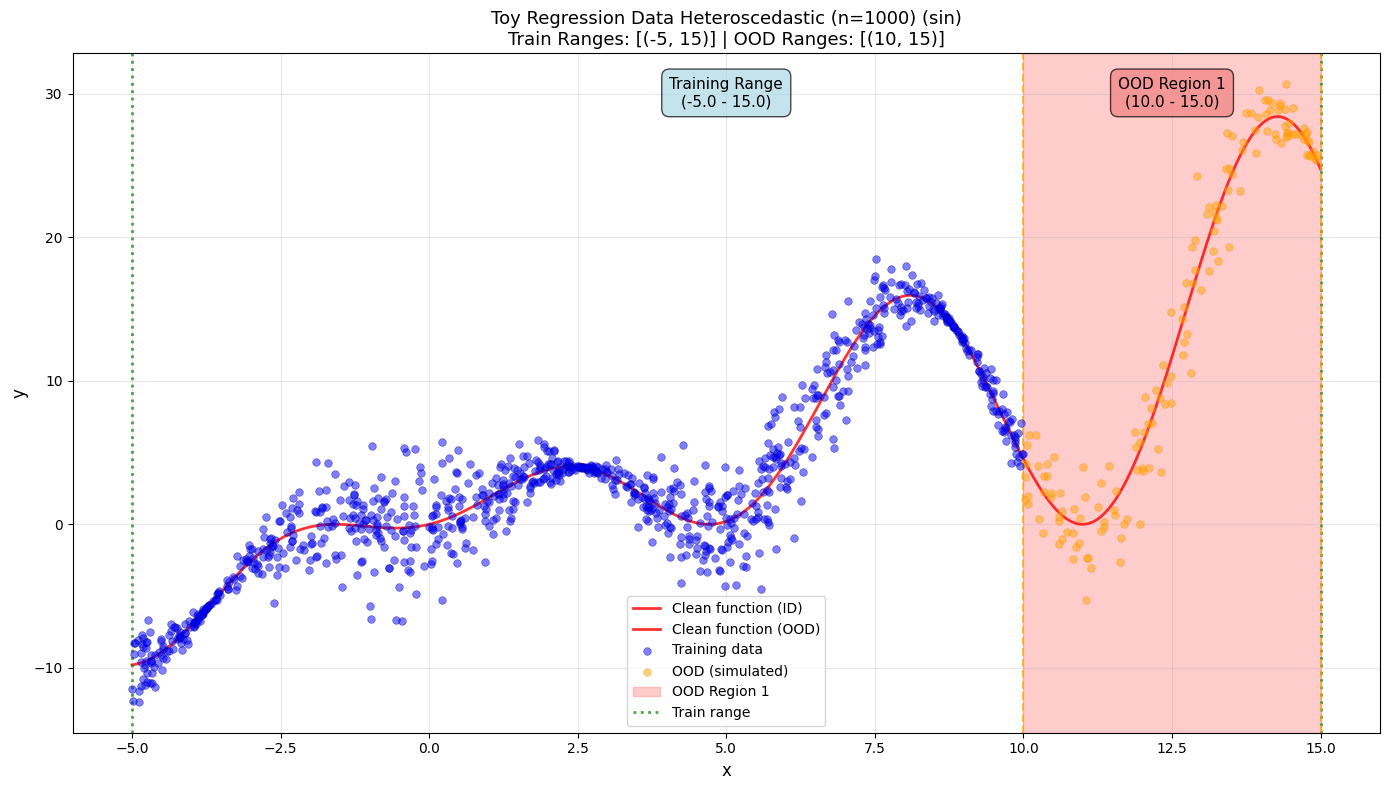

In [7]:
plot_data_with_ood_regions(
    x_train, y_train, x_grid, y_clean,
    train_range=(-5, 15),
    ood_ranges=[(10, 15)],
    x_ood=x_ood,   # <-- pass the OOD x from step 1
    y_ood=y_ood,   # <-- pass the OOD y from step 1
    title="Toy Regression Data Heteroscedastic (n=1000)",
    func_type='sin'
)

### Set parameters


In [ ]:
n_train = 1000
train_range = (-5, 10)
ood_ranges = [(10, 15)]  # List of (min, max) tuples for OOD regions
grid_points = 1500
seed = 42
torch.manual_seed(seed)


In [ ]:
run_mc_dropout_ood_experiment(
    generate_toy_regression_func=generate_toy_regression,
    function_types=['sin'],
    noise_type='heteroscedastic',
    train_range=train_range,
    ood_ranges=ood_ranges,
    n_train=n_train,
    grid_points=grid_points,
    seed=seed,
    beta=0.5,
    lr=1e-3,
    batch_size=32,
    p=0.25,
    mc_samples=20
)

## MC Dropout 


In [ ]:
### homo ###

run_mc_dropout_ood_experiment(
    generate_toy_regression_func=generate_toy_regression,
    function_types=['linear', 'sin'],
    noise_type='homoscedastic',
    train_range=train_range,
    ood_ranges=ood_ranges,
    n_train=n_train,
    grid_points=grid_points,
    seed=seed,
    beta=0.5,
    lr=1e-3,
    batch_size=32
)

### hetero ###

run_mc_dropout_ood_experiment(
    generate_toy_regression_func=generate_toy_regression,
    function_types=['linear', 'sin'],
    noise_type='heteroscedastic',
    train_range=train_range,
    ood_ranges=ood_ranges,
    n_train=n_train,
    grid_points=grid_points,
    seed=seed,
    beta=0.5,
    lr=1e-3,
    batch_size=32
)

## Deep Ensemble


In [ ]:
## homo ###

run_deep_ensemble_ood_experiment(
    generate_toy_regression_func=generate_toy_regression,
    function_types=['linear', "sin"],
    noise_type='homoscedastic',
    train_range=train_range,
    ood_ranges=ood_ranges,
    n_train=n_train,
    grid_points=grid_points,
    seed=seed,
    beta=0.5,
    batch_size=32
)

### hetero ###

run_deep_ensemble_ood_experiment(
    generate_toy_regression_func=generate_toy_regression,
    function_types=['linear', 'sin'],
    noise_type='heteroscedastic',
    train_range=train_range,
    ood_ranges=ood_ranges,
    n_train=n_train,
    grid_points=grid_points,
    seed=seed,
    beta=0.5,
    batch_size=32
)


## BNN - Homoscedastic


In [ ]:
### homo ###

# run_bnn_ood_experiment(
#     generate_toy_regression_func=generate_toy_regression,
#     function_types=['linear', 'sin'],
#     noise_type='homoscedastic',
#     train_range=train_range,
#     ood_ranges=ood_ranges,
#     n_train=n_train,
#     grid_points=grid_points,
#     seed=seed,
#     hidden_width=16,
#     weight_scale=1.0,
#     warmup=500,
#     samples=500,
#     chains=4
# )

# ### hetero ###

# run_bnn_ood_experiment(
#     generate_toy_regression_func=generate_toy_regression,
#     function_types=['linear', 'sin'],
#     noise_type='heteroscedastic',
#     train_range=train_range,
#     ood_ranges=ood_ranges,
#     n_train=n_train,
#     grid_points=grid_points,
#     seed=seed,
#     hidden_width=16,
#     weight_scale=1.0,
#     warmup=500,
#     samples=500,
#     chains=4
# )


## BAMLSS - Homoscedastic


In [ ]:
### homo ###

run_bamlss_ood_experiment(
    generate_toy_regression_func=generate_toy_regression,
    function_types=['linear', 'sin'],
    noise_type='homoscedastic',
    train_range=train_range,
    ood_ranges=ood_ranges,
    n_train=n_train,
    grid_points=grid_points,
    seed=seed,
    n_iter=12000,
    burnin=2000,
    thin=10,
    nsamples=1000
)

### hetero ###

run_bamlss_ood_experiment(
    generate_toy_regression_func=generate_toy_regression,
    function_types=['linear', 'sin'],
    noise_type='heteroscedastic',
    train_range=train_range,
    ood_ranges=ood_ranges,
    n_train=n_train,
    grid_points=grid_points,
    seed=seed,
    n_iter=12000,
    burnin=2000,
    thin=10,
    nsamples=1000
    
)


In [ ]:
## Save Combined Results

from utils.ood_experiments import save_all_ood_statistics
from datetime import datetime

date = datetime.now().strftime('%Y%m%d')

# Save combined Excel files and panel plots for homoscedastic noise
print(f"\n{'='*80}")
print("Saving combined results for homoscedastic noise...")
print(f"{'='*80}\n")
save_all_ood_statistics(noise_type='homoscedastic', date=date)

# Save combined Excel files and panel plots for heteroscedastic noise
print(f"\n{'='*80}")
print("Saving combined results for heteroscedastic noise...")
print(f"{'='*80}\n")
save_all_ood_statistics(noise_type='heteroscedastic', date=date)
